# Module 03: EDA

In [1]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [2]:
# Load the data
Hitters = load_data('Hitters')
Hitters 

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [3]:
#fillin
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [4]:
for col in Hitters:
    print(col, Hitters[col].dtype)
    

AtBat int64
Hits int64
HmRun int64
Runs int64
RBI int64
Walks int64
Years int64
CAtBat int64
CHits int64
CHmRun int64
CRuns int64
CRBI int64
CWalks int64
League category
Division category
PutOuts int64
Assists int64
Errors int64
Salary float64
NewLeague category


### Before doing any other analyses, let's create training and test sets.

In [5]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 

### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

#fillin Type your answer here
The 6 columns that start with C are "career"
cols = [Hitters[col] for col in Hitters if col[0] == 0]

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

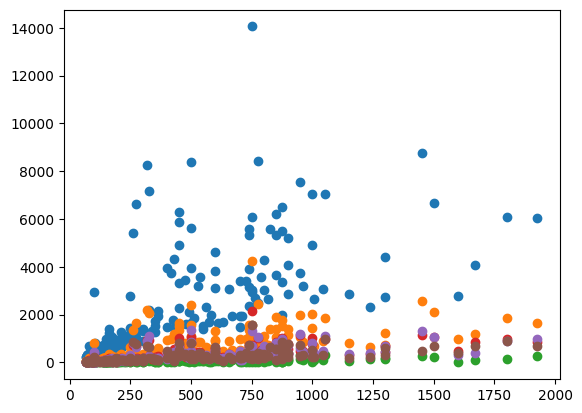

In [6]:
#fillin
career_cols = [Train[col] for col in Train if col[0].lower() == 'c']

#plt.scatter(Train['Salary'], career_cols)
for c in career_cols:
    plt.scatter(Train['Salary'], c)
    


### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [7]:
Train.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,164.000000
mean,381.829016,101.549223,10.150259,50.751295,47.093264,38.445596,7.253886,2587.440415,702.222798,59.668394,345.378238,308.373057,248.388601,276.865285,105.300518,8.051813,493.032951
std,145.679181,44.267521,8.228711,24.784284,24.912589,21.136915,4.858712,2285.947344,649.010165,66.449102,322.848870,297.885894,250.777436,262.957701,137.135778,6.783667,386.159522
min,19.000000,7.000000,0.000000,1.000000,2.000000,1.000000,1.000000,41.000000,13.000000,0.000000,3.000000,4.000000,4.000000,0.000000,0.000000,0.000000,67.500000
25%,271.000000,68.000000,4.000000,32.000000,29.000000,22.000000,3.000000,730.000000,185.000000,14.000000,98.000000,82.000000,63.000000,109.000000,7.000000,3.000000,160.000000
50%,369.000000,95.000000,8.000000,47.000000,43.000000,34.000000,6.000000,1876.000000,476.000000,36.000000,238.000000,202.000000,166.000000,211.000000,38.000000,6.000000,420.833500
75%,508.000000,136.000000,14.000000,68.000000,61.000000,53.000000,11.000000,3754.000000,1000.000000,78.000000,494.000000,419.000000,332.000000,317.000000,173.000000,12.000000,750.000000
max,687.000000,223.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,315.000000,2165.000000,1348.000000,1566.000000,1320.000000,492.000000,32.000000,1925.571000


### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

Text(0, 0.5, 'Freq')

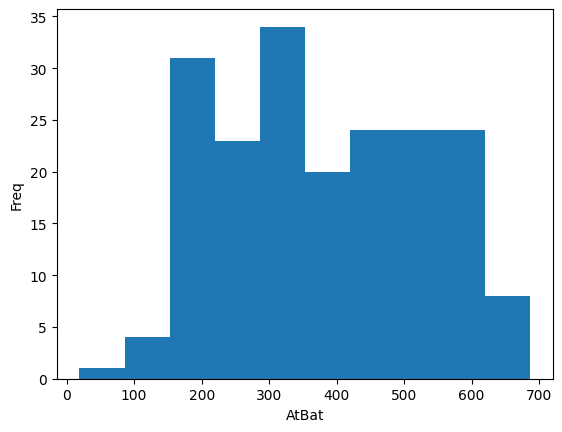

In [8]:
plt.hist(Train['AtBat'])
plt.xlabel('AtBat')
plt.ylabel('Freq')

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [9]:
AB_data = Train['AtBat']
mean = np.mean(AB_data)
std_dev = np.std(AB_data)
Train['AtBat_st'] = (AB_data - mean) / std_dev
Train['AtBat_st'].describe()

count    1.930000e+02
mean    -2.070882e-17
std      1.002601e+00
min     -2.497081e+00
25%     -7.627532e-01
50%     -8.829251e-02
75%      8.683405e-01
max      2.100264e+00
Name: AtBat_st, dtype: float64

### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [10]:
len(Train[AB_data < np.quantile(AB_data, 0.25) ])

48

### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

By looking at the 'count' row in the description table, you can see that all cols except Salary have 193 values, while Salary only has 164 values, meaning it's missing some

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

A case where this could happen is if you were to receive data with non-standard placeholder values. So for example, instead of NaN values, the data may have strings like 'missing' or 'n/a' which are still technically  string data, so they get counted as valid items in "Count."

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

C:\Users\annac\AppData\Local\Temp\ipykernel_43832\1571219745.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([AB_salary, AB_empty_salary], labels=['salary', 'empty salary'])


Text(0, 0.5, 'AtBat')

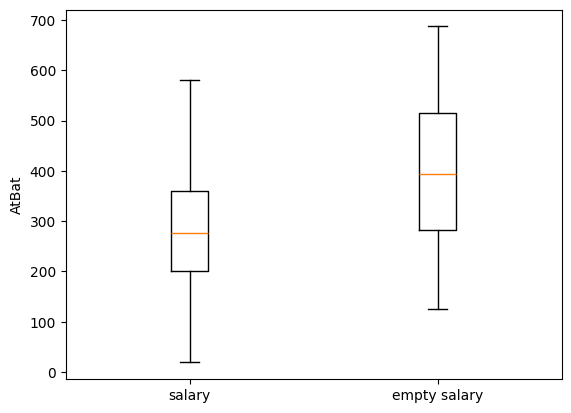

In [11]:
salary_mask = np.isnan(Train['Salary'])
AB_salary = Train[salary_mask]['AtBat']
AB_empty_salary = Train[~salary_mask]['AtBat']
plt.boxplot([AB_salary, AB_empty_salary], labels=['salary', 'empty salary'])
plt.ylabel('AtBat')


### Create a correlation matrix for all numeric features in the training set

In [12]:
#fillin
num_train = Train.select_dtypes(include=[np.number])
corr_mat = num_train.corr()
corr_mat

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,AtBat_st
AtBat,1.000000,0.963324,0.540323,0.906579,0.798717,0.631824,-0.039232,0.126602,0.146763,0.150166,0.164892,0.145779,0.056578,0.345879,0.363085,0.368162,0.401390,1.000000
Hits,0.963324,1.000000,0.516853,0.914739,0.795316,0.605876,-0.028717,0.133316,0.163329,0.136865,0.175542,0.153011,0.065178,0.312858,0.310422,0.301725,0.432558,0.963324
HmRun,0.540323,0.516853,1.000000,0.618439,0.840613,0.385425,0.009072,0.078981,0.076914,0.411917,0.110767,0.218285,0.080296,0.222084,-0.069088,0.062840,0.326021,0.540323
Runs,0.906579,0.914739,0.618439,1.000000,0.786635,0.711346,-0.069584,0.083770,0.103859,0.160979,0.159683,0.115628,0.099025,0.289952,0.184714,0.217297,0.441499,0.906579
RBI,0.798717,0.795316,0.840613,0.786635,1.000000,0.553527,0.046705,0.165837,0.180526,0.375072,0.191452,0.285074,0.117109,0.323825,0.138896,0.217983,0.414623,0.798717
Walks,0.631824,0.605876,0.385425,0.711346,0.553527,1.000000,0.037943,0.137157,0.147019,0.194766,0.205250,0.167453,0.312812,0.317000,0.139008,0.160753,0.458462,0.631824
Years,-0.039232,-0.028717,0.009072,-0.069584,0.046705,0.037943,1.000000,0.925308,0.906857,0.730478,0.882559,0.882835,0.836809,0.071301,-0.091915,-0.160476,0.541390,-0.039232
CAtBat,0.126602,0.133316,0.078981,0.083770,0.165837,0.137157,0.925308,1.000000,0.995185,0.775167,0.979705,0.948617,0.894573,0.120875,-0.000507,-0.068187,0.616677,0.126602
CHits,0.146763,0.163329,0.076914,0.103859,0.180526,0.147019,0.906857,0.995185,1.000000,0.761920,0.983128,0.945002,0.883547,0.132818,-0.003372,-0.062669,0.629875,0.146763
CHmRun,0.150166,0.136865,0.411917,0.160979,0.375072,0.194766,0.730478,0.775167,0.761920,1.000000,0.782490,0.912134,0.750795,0.126756,-0.129640,-0.141514,0.616170,0.150166


### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

1. You could use the correlation matrix to choose variables with higher correlation to Salary and then use these variables as predictors in a linear regression model. You would then train the model using filled columns, specifically choosing columns with higher correlation to salary (e.g. above 0.5). You would then test the model on empty salary values, using values from the same row as the missing salary val as input.

2. Using the boxplot, you could group salary according to its relationship to AtBat's distribution. Seperate Salary values into groups depending on whether their corresponding AtBat value fall into the range of min-Q1, Q1-Q2, Q2-Q3, and Q3-max. Then, calculate descriptive statistics for the salary values within each of these groups. For unknown salary values, place them into a corresponding group based on their AtBat value and then use the given median or mean to predict the missing value.

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

In [13]:
year_cols = [col for col in Train.columns if col[0] != 'c']
Train_86 = Train[year_cols]
TotHits = sum(Train_86['Hits'])
TotWalks = sum(Train_86['Years'])
TotAtBat = sum(Train_86['AtBat'])

Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat-TotHits-TotWalks]

([<matplotlib.patches.Wedge at 0x21bada48560>,
 [Text(0.7378702360346723, 0.815810955291811, 'Hits'),
  Text(-0.17517352996215382, 1.0859623540439136, 'Walks'),
  Text(-0.687895267395189, -0.8583706082429089, 'Neither')])

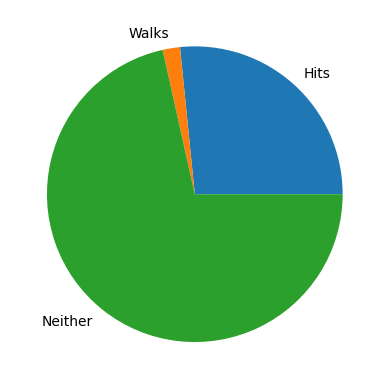

In [14]:
# pie chart
plt.pie(Totals, labels=Labels)


### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [ ]:
Train['AVG'] = Train['Hits'] / Train['AtBat']

3      0.284274
63     0.245370
27     0.272152
130    0.339869
93     0.270059
         ...   
308    0.233333
90     0.264331
147    0.305509
232    0.265176
72     0.255859
Name: AVG, Length: 193, dtype: float64

### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [ ]:
Train['AVG_bin'] = 'medium'
Train['AVG_bin'][Train['AVG'] < 0.25] = 'low'
Train['AVG_bin'][Train['AVG'] > 0.31] = 'high'

C:\Users\annac\AppData\Local\Temp\ipykernel_43832\2512436611.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Train['AVG_bin'][Train['AVG'] < 0.25] = 'low'
C:\Users\annac\AppData\Local\Temp\ipykernel_43832\2512436611.py:2: SettingWithCopy

3      medium
63        low
27     medium
130      high
93     medium
        ...  
308       low
90     medium
147    medium
232    medium
72     medium
Name: AVG_bin, Length: 193, dtype: object

### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

<Axes: xlabel='AVG_bin'>

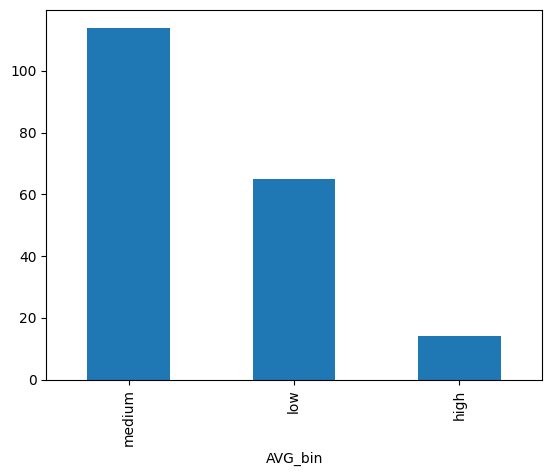

In [31]:
Train['AVG_bin'].value_counts().plot(kind='bar')



Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [19]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts()[i] for i in indexMap]

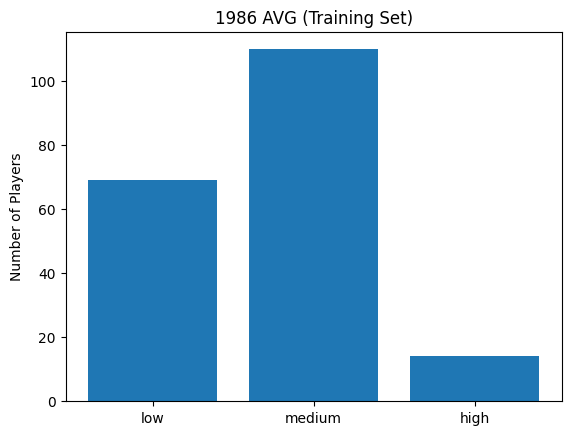

In [32]:
plt.bar(indexMap, reordered_list)

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks(indexMap)

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

We used the width method, because we chose specific cutoff values. We can see by the player count charts (Which base their values on the num of entries within our categories) that the categories are not equal in size. If we used the depth method, these categories would all be uniform in their number of entries.